# Polars, hands-on — *"When the DataFrame Broke"*
### Big Data Analytics · MBA (Business Analytics) · Session 2 · QuickKart

This notebook is the lab that goes with Session 2. It:

- **generates its own sample data** — nothing to download, no file to ship;
- **runs identically on macOS and Windows** (and Linux) — every path uses `pathlib`, every install targets the current interpreter;
- follows the same story as the lecture — filter out tiny orders, group by region, find the top region.

**How to run:** *Kernel → Restart & Run All* (Jupyter) or *Run All* (VS Code). The first cell installs Polars if it is missing.

> Cross-platform notes are called out like this whenever a line was written to behave the same on Mac and Windows.

---

### What each section covers

| Section | What it teaches |
|---|---|
| 0 · Setup | Install Polars into *this* interpreter, safely on every OS |
| 1 · Generate the sample data | Build a realistic, seasonal QuickKart order log — 6 regions, 10 categories, 3 months of dates |
| 1b · Seasonality check | Confirm the festive-sale skew we built in actually shows up |
| 2 · Eager vs. lazy | `read_csv` (eager) vs. `scan_csv` (lazy) — the core Polars concept |
| 3 · The business question | One real lazy pipeline: filter → group → aggregate → sort |
| 4 · Why lazy can be faster | `.explain()` — predicate pushdown and projection pushdown |
| 5 · Same logic in pandas | Syntax comparison, for students coming from pandas |
| 6 · Your turn | A fill-in-the-blanks practice exercise with a self-check solution |
| 7 · Recap | Summary + cross-platform checklist |


## 0 · Setup — make sure Polars is installed

We install into **the same Python that is running this notebook** using `sys.executable`.
That is the one line people get wrong: a bare `pip install` can target a *different* Python on
Windows than the kernel you are using. `sys.executable` avoids that on every OS.

**Why this matters:** on Windows especially, it's common to have several Pythons installed (one from
python.org, one bundled with Anaconda, one from the Microsoft Store). Running `pip install polars` in
a terminal can install into a *different* Python than the one Jupyter's kernel is using — so the import
still fails even though "pip said it worked." Calling `[sys.executable, "-m", "pip", "install", ...]`
sidesteps that entirely: it always installs into the exact interpreter that is running this notebook.

The `ensure()` helper below tries to `import` first and only installs if that fails, so re-running the
notebook doesn't reinstall Polars every single time.


In [1]:
import importlib, subprocess, sys  # standard-library tools for checking/installing packages

def ensure(module_name, pip_name=None):
    "Import a package; if missing, install it into THIS interpreter (Mac/Win/Linux safe)."
    try:
        return importlib.import_module(module_name)  # try to load the package if it's already installed
    except ImportError:
        print(f"Installing {pip_name or module_name} ...")  # tell the user we're about to install it
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or module_name])  # install it into this interpreter
        return importlib.import_module(module_name)  # now that it's installed, load it

pl = ensure("polars")  # make sure Polars is installed, then load it as "pl"
print("Polars version:", pl.__version__)  # show which version of Polars we're using
print("Running on     :", sys.platform)   # 'darwin' = macOS, 'win32' = Windows, 'linux' = Linux


Polars version: 1.43.0
Running on     : darwin


In [2]:
import random  # standard-library module for generating random numbers
from pathlib import Path  # standard-library module for building file paths safely

# Cross-platform folder + file paths. Path() joins with the RIGHT separator
# on every OS ('/' on Mac, '\\' on Windows) — never hard-code slashes.
DATA_DIR = Path.cwd() / "quickkart_data"  # folder where we'll store our generated data
DATA_DIR.mkdir(exist_ok=True)  # create that folder if it doesn't already exist
CSV_PATH = DATA_DIR / "quickkart_orders.csv"  # full path to the CSV file we will create

print("Data folder:", DATA_DIR)  # show the folder path
print("CSV file   :", CSV_PATH)  # show the CSV file path


Data folder: /Users/abhisheksarkar/code/nmims/nmims_analytics/nyb_windows/quickkart_data
CSV file   : /Users/abhisheksarkar/code/nmims/nmims_analytics/nyb_windows/quickkart_data/quickkart_orders.csv


In [3]:
import datetime  # standard-library module for representing calendar dates

random.seed(42)   # fix the "random" starting point so everyone gets the same data on every machine

REGIONS = [  # India's 6 official zonal council divisions — more realistic than a generic 5-way split
    "North", "South", "East", "West", "Central", "Northeast",
]
CATEGORIES = [  # 10 categories — a broader, more realistic QuickKart catalog
    "Groceries", "Electronics", "Apparel", "Pharmacy", "Home",
    "Beauty & Personal Care", "Toys & Games", "Sports & Fitness",
    "Stationery & Books", "Pet Supplies",
]
N = 50_000  # how many fake orders we want to generate

# --- Date range + festive-sale window, for seasonality ---
START_DATE = datetime.date(2025, 9, 1)     # data starts here
END_DATE = datetime.date(2025, 11, 30)     # data ends here
FESTIVE_START = datetime.date(2025, 10, 15)  # Diwali festive-sale window starts here
FESTIVE_END = datetime.date(2025, 11, 5)     # ...and ends here
FESTIVE_DAY_COUNT = (FESTIVE_END - FESTIVE_START).days + 1   # how many calendar days the festive window spans
TOTAL_DAY_COUNT = (END_DATE - START_DATE).days + 1            # how many calendar days the full range spans
REGULAR_DAY_COUNT = TOTAL_DAY_COUNT - FESTIVE_DAY_COUNT        # how many days are OUTSIDE the festive window

# Not every category is equally "giftable" or seasonal, and not every region shops the festive
# sale the same way — real festive demand is uneven, so we bake that unevenness in on purpose.
# Each multiplier below is a direct, realistic target: e.g. 2.0 means "this category's average
# daily revenue roughly DOUBLES during the festive window" — comparable to real festive-season
# upticks, not an artificial multiple-hundred-percent spike.
CATEGORY_FESTIVE_MULTIPLIER = {
    "Apparel": 2.2,                   # classic festive gifting/wardrobe-refresh category
    "Electronics": 2.0,               # big-ticket festive gifting category
    "Toys & Games": 1.85,             # gifting category, especially around Diwali
    "Beauty & Personal Care": 1.65,   # moderately gift-driven
    "Home": 1.45,                     # some festive home-decor demand
    "Sports & Fitness": 1.25,         # mild seasonal bump
    "Stationery & Books": 1.15,       # not particularly festive-driven
    "Pet Supplies": 1.08,             # steady, non-seasonal demand
    "Pharmacy": 1.03,                 # need-driven, not gift-driven — should stay nearly flat
    "Groceries": 1.00,                # daily staple — no festive bump at all
}
REGION_FESTIVE_MULTIPLIER = {
    "North": 1.50, "West": 1.40, "South": 1.25,
    "East": 1.15, "Central": 1.05, "Northeast": 1.00,
}

def random_order_date(category, region):
    "Pick a random date; festive-window days are weighted by this order's category/region multiplier."
    multiplier = (CATEGORY_FESTIVE_MULTIPLIER[category] + REGION_FESTIVE_MULTIPLIER[region]) / 2
    # Weighted odds of landing in the festive window vs. outside it, given that multiplier.
    # This gives an EXACT expected avg-daily-revenue ratio of `multiplier` between the two periods,
    # regardless of how long the festive window is relative to the full range (unlike a flat
    # "45% of orders" rule, which would conflate window length with the actual demand multiplier).
    festive_weight = FESTIVE_DAY_COUNT * multiplier
    regular_weight = REGULAR_DAY_COUNT * 1.0
    p_festive = festive_weight / (festive_weight + regular_weight)
    if random.random() < p_festive:
        offset = random.randint(0, FESTIVE_DAY_COUNT - 1)
        return FESTIVE_START + datetime.timedelta(days=offset)
    while True:   # rejection-sample a day outside the festive window (window is short, so this is cheap)
        offset = random.randint(0, TOTAL_DAY_COUNT - 1)
        candidate = START_DATE + datetime.timedelta(days=offset)
        if not (FESTIVE_START <= candidate <= FESTIVE_END):
            return candidate

rows = []  # empty list that will hold one entry per order
for order_id in range(1, N + 1):        # repeat once for every order, numbered 1 to 50,000
    region   = random.choice(REGIONS)     # pick one region at random for this order
    category = random.choice(CATEGORIES)  # pick one category at random for this order
    order_date = random_order_date(category, region)  # pick a date, weighted by this category/region's festive multiplier
    # ~30% tiny orders below 500, the rest larger — so the >500 filter actually does something
    if random.random() < 0.30:  # 30% of the time, make this a small order
        order_value = round(random.uniform(50, 500), 2)    # random small order value, rounded to 2 decimals
    else:  # the other 70% of the time
        order_value = round(random.uniform(500, 8000), 2)  # random larger order value, rounded to 2 decimals
    units = random.randint(1, 5)  # random number of items bought, between 1 and 5
    rows.append((order_id, region, category, order_value, units, order_date.isoformat()))  # save this order as one row of data

orders = pl.DataFrame(  # build a Polars table (DataFrame) out of all the rows we generated
    rows,
    schema=["OrderID", "Region", "Category", "OrderValue", "Units", "OrderDate"],  # name each column
    orient="row",  # tell Polars our data is a list of rows (not columns)
)

# write_csv accepts a pathlib.Path directly and picks the OS-correct path — cross-platform.
orders.write_csv(CSV_PATH)  # save the table to a CSV file on disk
print(f"Wrote {orders.height:,} rows to {CSV_PATH.name}")  # confirm how many rows were written
print(f"Regions: {len(REGIONS)}  |  Categories: {len(CATEGORIES)}  |  Date range: {START_DATE} to {END_DATE}")
orders.head()  # preview the first few rows of the table


Wrote 50,000 rows to quickkart_orders.csv
Regions: 6  |  Categories: 10  |  Date range: 2025-09-01 to 2025-11-30


OrderID,Region,Category,OrderValue,Units,OrderDate
i64,str,str,f64,i64,str
1,"""Northeast""","""Electronics""",112.79,1,"""2025-10-23"""
2,"""Northeast""","""Stationery & Books""",92.16,2,"""2025-10-28"""
3,"""Central""","""Pet Supplies""",5759.94,4,"""2025-10-21"""
4,"""South""","""Sports & Fitness""",1697.44,4,"""2025-09-01"""
5,"""East""","""Home""",220.97,3,"""2025-10-25"""


In [4]:
monthly = (
    pl.scan_csv(CSV_PATH)                                         # lazy: nothing runs yet
      .with_columns(pl.col("OrderDate").str.slice(0, 7).alias("Month"))  # "YYYY-MM-DD" -> "YYYY-MM"
      .group_by("Month")                                           # one group per calendar month
      .agg(
          pl.len().alias("NumberOfOrders"),                        # how many orders that month
          pl.col("OrderValue").sum().round(2).alias("TotalSales"),  # total sales that month
      )
      .sort("Month")                                                # chronological order
      .collect()
)
monthly


Month,NumberOfOrders,TotalSales
str,u32,f64
"""2025-09""",15271,4.6343e7
"""2025-10""",18560,5.6475e7
"""2025-11""",16169,4.9191e7


In [5]:
eager = pl.read_csv(CSV_PATH)          # runs immediately — reads the whole file into memory now (eager)
lazy  = pl.scan_csv(CSV_PATH)          # builds a plan only — reads nothing yet (lazy)

print("read_csv  ->", type(eager).__name__)   # DataFrame  (eager)
print("scan_csv  ->", type(lazy).__name__)     # LazyFrame  (lazy)


read_csv  -> DataFrame
scan_csv  -> LazyFrame


In [6]:
query = (
    pl.scan_csv(CSV_PATH)                                   # lazy: nothing runs yet, just opens a plan to read the CSV
      .filter(pl.col("OrderValue") > 500)                   # step 1: drop tiny orders (500 or below)
      .group_by("Region")                                   # step 2: one group per region
      .agg(                                                 # step 3: compute these numbers for each group
          pl.len().alias("NumberOfOrders"),                 #   - how many orders in this region
          pl.col("OrderValue").sum().round(2).alias("TotalSales"),        #   - total sales in this region
          pl.col("OrderValue").mean().round(2).alias("AverageOrderValue"),#   - average order value in this region
      )
      .sort("TotalSales", descending=True)                  # step 4: sort regions, highest total sales first
)

result = query.collect()    # <-- THIS line actually runs the whole pipeline and gives us a real table
result   # display the resulting table


Region,NumberOfOrders,TotalSales,AverageOrderValue
str,u32,f64,f64
"""Northeast""",5805,2.4843e7,4279.56
"""North""",5795,2.4803e7,4280.11
"""East""",5852,2.4767e7,4232.3
"""South""",5818,2.4521e7,4214.6
"""Central""",5729,2.4489e7,4274.64
"""West""",5761,2.4360e7,4228.45


In [7]:
top = result.row(0, named=True)  # grab the first row (the top region) as a named, dictionary-like object
print(f"Top region: {top['Region']}  "  # print a friendly summary sentence built from that row's values
      f"(TotalSales = {top['TotalSales']:,.2f} INR across {top['NumberOfOrders']:,} orders)")


Top region: Northeast  (TotalSales = 24,842,837.78 INR across 5,805 orders)


In [8]:
plan = (
    pl.scan_csv(CSV_PATH)                                    # start the same lazy plan as before
      .filter(pl.col("OrderValue") > 500)                    # keep only orders above 500
      .group_by("Region")                                    # group the remaining orders by region
      .agg(pl.col("OrderValue").sum().alias("TotalSales"))    # add up OrderValue per region
)
print(plan.explain())     # print the optimized query plan (read it bottom-up) — nothing is executed yet


AGGREGATE[maintain_order: false]
  [col("OrderValue").sum().alias("TotalSales")] BY [col("Region")]
  FROM
  Csv SCAN [/Users/abhisheksarkar/code/nmims/nmims_analytics/nyb_windows/quickkart_data/quickkart_orders.csv]
  PROJECT 2/6 COLUMNS
  SELECTION: col("OrderValue") > 500.0
  ESTIMATED ROWS: 52105


In [9]:
try:
    import pandas as pd                               # try to load pandas, a different (older, eager-only) data library
    pdf = pd.read_csv(CSV_PATH)                       # eager: whole file into memory now
    big = pdf[pdf["OrderValue"] > 500]                # keep only rows where OrderValue is above 500
    summary = (big.groupby("Region")["OrderValue"]    # group the filtered rows by region
                  .agg(["count", "sum", "mean"])        # compute count, total, and average per region
                  .sort_values("sum", ascending=False)   # sort so the highest total is first
                  .round(2))                             # round the numbers to 2 decimal places
    print("pandas result (same question):")   # label the output so it's clear what follows
    print(summary)   # show the pandas result
except ImportError:
    print("pandas not installed — skipping the comparison (Polars result above is enough).")  # skip gracefully if pandas is missing


pandas result (same question):
           count          sum     mean
Region                                
Northeast   5805  24842837.78  4279.56
North       5795  24803211.59  4280.11
East        5852  24767413.05  4232.30
South       5818  24520539.29  4214.60
Central     5729  24489429.94  4274.64
West        5761  24360071.90  4228.45


## 6 · Your turn — fill in the blanks

Rebuild the same answer from scratch. Replace each `____` and run the cell.
The logic is the one you already know: **filter → group → aggregate → sort**.

The next cell is intentionally commented out (so "Run All" doesn't error on the blanks) — uncomment it,
fill in the four blanks, and run it yourself before checking the model solution below.


In [18]:
# --- model solution (run to check your work) ---
solution = (
    pl.scan_csv(CSV_PATH)                                              # open the CSV file, but don't read it yet — just get ready to
      .filter(pl.col("OrderValue") > 500)                              # keep only the orders worth more than 500
      .group_by("Region")                                              # put every order into one bucket per region
      .agg(pl.col("OrderValue").sum().round(2).alias("TotalSales"))    # add up all the order values in each region's bucket
      .sort("TotalSales", descending=True)                             # put the region with the biggest total at the top
)
solution.collect()   # now actually do all of the above, and show the resulting table


Region,TotalSales
str,f64
"""Northeast""",2.4843e7
"""North""",2.4803e7
"""East""",2.4767e7
"""South""",2.4521e7
"""Central""",2.4489e7
"""West""",2.4360e7


## 7 · Recap

- `pl.read_csv` is **eager**; `pl.scan_csv` is **lazy** — the word *scan* is the tell.
- A lazy pipeline runs only at the **trigger**: `.collect()` (or `.sink_csv()` to write straight to disk).
- Laziness lets the optimizer do **predicate pushdown** and **projection pushdown** — less data read, faster answer.
- The verbs never changed from pandas: **filter → group → aggregate → sort**. Only the engine did.
- Real-world data has **seasonality** (the festive-sale skew we built into `OrderDate`) — always sanity-check
  that a data-generation assumption actually shows up before building analysis on top of it (section 1b).

**Cross-platform checklist used in this notebook:** `sys.executable` for installs · `pathlib.Path`
for every path · standard-library `random`/`datetime` for data · `write_csv`/`scan_csv` take `Path` objects directly.
Nothing here is Mac-only or Windows-only.


## 8 · Business Case — Should QuickKart Roll Out More Festive Offers?

**The situation.** QuickKart's Growth team is planning next year's festive-sale calendar. Running a
promotion (extra ad spend, discount codes, warehouse staffing) costs money in every category and
region — so rolling it out *everywhere* isn't free, and rolling it out *nowhere* leaves money on the
table if demand really does spike on its own. The team needs to decide: **where does a festive push
actually pay off, and where would it just be a discount on sales that were happening anyway?**

**Our approach.** We don't have a controlled experiment (no A/B test where some categories got a
discount and others didn't) — this is real-world messiness. What we *do* have is 3 months of order
data that naturally spans a festive window (Oct 15 - Nov 5) and two "normal" periods around it. We'll
treat the **organic demand spike during that window** as a signal: categories and regions where demand
already surges without any special intervention are the ones most likely to respond well to a
deliberate push. Categories that stay flat are telling us something too — a discount there is more
likely to just erode margin on sales that would have happened anyway.

**How to read this section as a class exercise.** Walk through each chart in order and ask, out loud,
"what would a Growth PM do with this number?" before reading the recommendation cell. The charts build
on each other: first we see *where* the revenue is (8a), then *whether* the festive window is real
(8b), then *who specifically* responds to it (8c, 8d), and only then do we turn that into a decision (8e).


### 8a · Where does the revenue come from today?

Before asking "should we push harder," a manager needs the baseline: which categories and regions
already carry the business? A festive push on a category that's 2% of revenue matters a lot less than
one on a category that's 20% of revenue, even if the second one's festive lift turns out smaller.


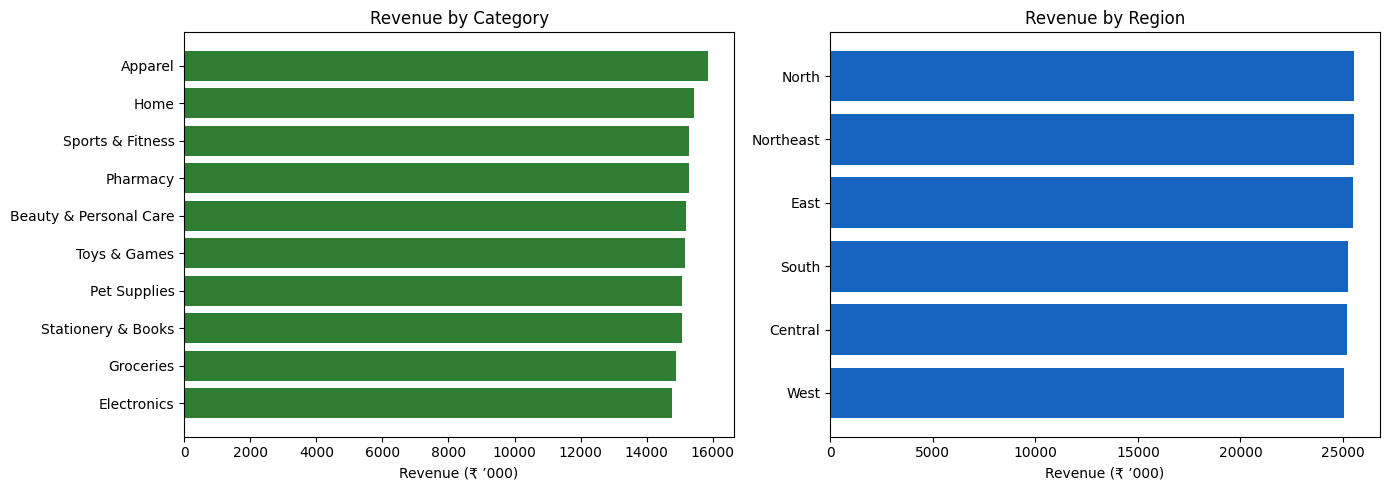

In [11]:
category_revenue = (
    pl.scan_csv(CSV_PATH)
      .group_by("Category")
      .agg(pl.col("OrderValue").sum().round(2).alias("TotalRevenue"))
      .sort("TotalRevenue", descending=True)
      .collect()
)
region_revenue = (
    pl.scan_csv(CSV_PATH)
      .group_by("Region")
      .agg(pl.col("OrderValue").sum().round(2).alias("TotalRevenue"))
      .sort("TotalRevenue", descending=True)
      .collect()
)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Divide by 1,000 for the chart only (the underlying category_revenue/region_revenue tables
# keep full-precision rupee values) \u2014 large 6-7 digit labels are hard to read on a bar axis,
# so we show revenue in \u20b9 thousands instead.
axes[0].barh(category_revenue["Category"].to_list()[::-1], (category_revenue["TotalRevenue"] / 1000).to_numpy()[::-1], color="#2E7D32")
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Revenue (\u20b9 \u2019000)")

axes[1].barh(region_revenue["Region"].to_list()[::-1], (region_revenue["TotalRevenue"] / 1000).to_numpy()[::-1], color="#1565C0")
axes[1].set_title("Revenue by Region")
axes[1].set_xlabel("Revenue (\u20b9 \u2019000)")

plt.tight_layout()
plt.show()


### 8b · Does demand actually spike in the festive window?

Section 1b already checked this at the monthly level. Here we zoom into **daily** revenue so the class
can see the shape of the spike, not just a monthly total — a real demand curve looks like a ramp-up and
ramp-down around the festive window, not a step function.


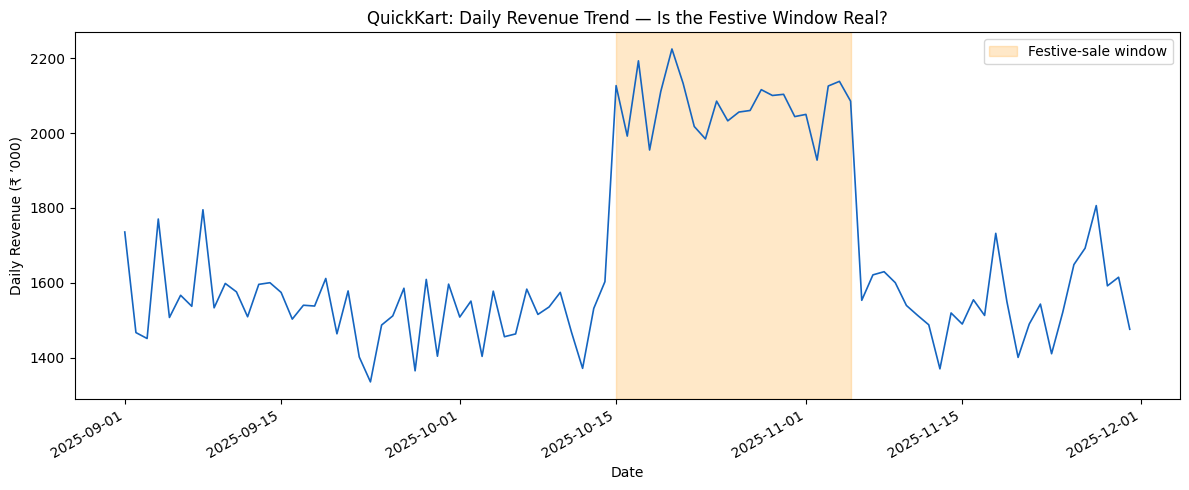

In [12]:
import datetime as dt

daily = (
    pl.scan_csv(CSV_PATH)
      .group_by("OrderDate")
      .agg(pl.col("OrderValue").sum().round(2).alias("TotalSales"))
      .sort("OrderDate")
      .collect()
)

daily_dates = [dt.date.fromisoformat(d) for d in daily["OrderDate"].to_list()]  # parse "YYYY-MM-DD" strings into real dates for the x-axis
daily_values_thousands = daily["TotalSales"].to_numpy() / 1000  # \u20b9 thousands, for a readable y-axis

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_dates, daily_values_thousands, color="#1565C0", linewidth=1.2)
ax.axvspan(FESTIVE_START, FESTIVE_END, color="#FFA726", alpha=0.25, label="Festive-sale window")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Revenue (\u20b9 \u2019000)")
ax.set_title("QuickKart: Daily Revenue Trend \u2014 Is the Festive Window Real?")
ax.legend()
fig.autofmt_xdate()   # angle the date labels so they don't overlap
plt.tight_layout()
plt.show()


### 8c · Which categories respond most to the festive window? (the "lift")

Total revenue in the festive window is misleading on its own — a category could look big there just
because it's big everywhere. Instead we compare **average daily revenue inside the festive window**
to **average daily revenue outside it**, per category. The percentage difference is the "festive lift"
— a clean, comparable number for every category regardless of its size.


In [13]:
orders_with_period = (
    pl.scan_csv(CSV_PATH)
      .with_columns(pl.col("OrderDate").str.to_date())   # parse the date string into a real Date column, once
      .with_columns(
          pl.when((pl.col("OrderDate") >= FESTIVE_START) & (pl.col("OrderDate") <= FESTIVE_END))
            .then(pl.lit("Festive"))
            .otherwise(pl.lit("Regular"))
            .alias("Period")   # label every order as falling inside or outside the festive window
      )
      .collect()
)

period_days = (
    orders_with_period.group_by("Period")
    .agg(pl.col("OrderDate").n_unique().alias("Days"))   # how many distinct calendar days are in each period
)

category_period_revenue = (
    orders_with_period.group_by(["Category", "Period"])
    .agg(pl.col("OrderValue").sum().alias("Revenue"))
    .join(period_days, on="Period")
    .with_columns((pl.col("Revenue") / pl.col("Days")).alias("AvgDailyRevenue"))
    # ^ normalize by number of days so a 3-week window is compared fairly against a ~2-month window
)

category_lift = (
    category_period_revenue
    .pivot(values="AvgDailyRevenue", index="Category", on="Period")   # one row per category, Festive/Regular as columns
    .with_columns(
        ((pl.col("Festive") / pl.col("Regular") - 1) * 100).round(1).alias("FestiveLiftPct")
    )
    .sort("FestiveLiftPct", descending=True)
)
category_lift


Category,Regular,Festive,FestiveLiftPct
str,f64,f64,f64
"""Apparel""",147048.823333,259407.542727,76.4
"""Electronics""",139525.986812,234055.561364,67.8
"""Toys & Games""",147983.07913,225537.954091,52.4
"""Beauty & Personal Care""",150044.855072,219792.573182,46.5
"""Home""",156037.851449,211788.652273,35.7
"""Stationery & Books""",158460.137391,187813.567727,18.5
"""Pet Supplies""",158713.245797,187820.651818,18.3
"""Pharmacy""",160770.57,190093.455455,18.2
"""Sports & Fitness""",161499.602464,188164.151364,16.5


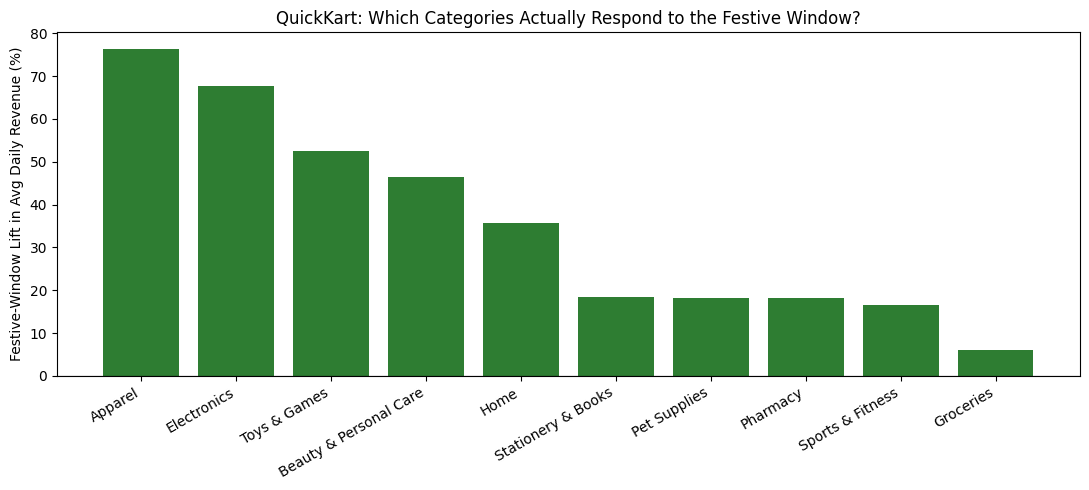

In [14]:
cats = category_lift["Category"].to_list()
lifts = category_lift["FestiveLiftPct"].to_numpy()
bar_colors = ["#2E7D32" if v >= 0 else "#C62828" for v in lifts]   # green = responds to the festive window, red = doesn't

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(cats, lifts, color=bar_colors)
ax.axhline(0, color="black", linewidth=0.8)   # 0% line: above it means the category spikes, below means it dips
ax.set_ylabel("Festive-Window Lift in Avg Daily Revenue (%)")
ax.set_title("QuickKart: Which Categories Actually Respond to the Festive Window?")
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 8d · Which regions respond most?

Same question, one level up — regions instead of categories. A regional lens matters for a different
reason than category: it tells the Growth team where to concentrate *marketing spend and logistics*
(local ads, delivery capacity) rather than which product lines to discount.


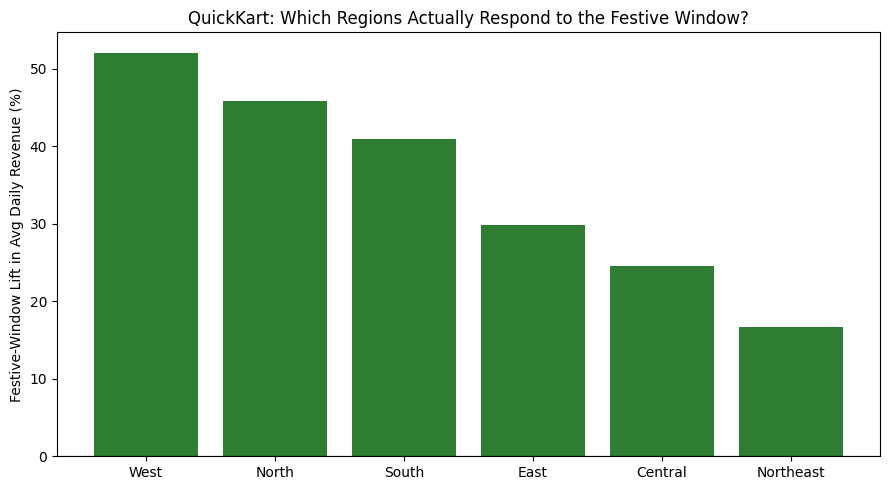

Region,Festive,Regular,FestiveLiftPct
str,f64,f64,f64
"""West""",372022.540455,244664.265797,52.1
"""North""",368368.014545,252512.057971,45.9
"""South""",355675.551364,252221.571449,41.0
"""East""",339233.240455,261065.557246,29.9
"""Central""",325415.395909,261231.745942,24.6
"""Northeast""",314747.378636,269591.153913,16.7


In [15]:
region_period_revenue = (
    orders_with_period.group_by(["Region", "Period"])
    .agg(pl.col("OrderValue").sum().alias("Revenue"))
    .join(period_days, on="Period")
    .with_columns((pl.col("Revenue") / pl.col("Days")).alias("AvgDailyRevenue"))
)

region_lift = (
    region_period_revenue
    .pivot(values="AvgDailyRevenue", index="Region", on="Period")
    .with_columns(
        ((pl.col("Festive") / pl.col("Regular") - 1) * 100).round(1).alias("FestiveLiftPct")
    )
    .sort("FestiveLiftPct", descending=True)
)

regs = region_lift["Region"].to_list()
reg_lifts = region_lift["FestiveLiftPct"].to_numpy()
reg_colors = ["#2E7D32" if v >= 0 else "#C62828" for v in reg_lifts]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(regs, reg_lifts, color=reg_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Festive-Window Lift in Avg Daily Revenue (%)")
ax.set_title("QuickKart: Which Regions Actually Respond to the Festive Window?")
plt.tight_layout()
plt.show()

region_lift


### 8e · Turning the analysis into a decision

This is the step a lot of analysis stops short of: the charts are interesting, but a Growth team needs
a **yes/no per category and region**, not just a chart. Here we turn the lift numbers into a concrete
recommendation, split at the *median* lift — categories/regions above the median are where a festive
push already resonates; below it, a discount is more likely to just be a markdown on demand that would
have shown up anyway.


In [16]:
category_median_lift = category_lift["FestiveLiftPct"].median()
extend_categories = category_lift.filter(pl.col("FestiveLiftPct") >= category_median_lift)["Category"].to_list()
hold_categories = category_lift.filter(pl.col("FestiveLiftPct") < category_median_lift)["Category"].to_list()

region_median_lift = region_lift["FestiveLiftPct"].median()
extend_regions = region_lift.filter(pl.col("FestiveLiftPct") >= region_median_lift)["Region"].to_list()
hold_regions = region_lift.filter(pl.col("FestiveLiftPct") < region_median_lift)["Region"].to_list()

print("RECOMMENDATION\n" + "=" * 60)
print(f"Extend / lean into festive offers \u2014 categories:\n  {', '.join(extend_categories)}")
print(f"\nHold off on category discounts (demand already flat) \u2014 categories:\n  {', '.join(hold_categories)}")
print(f"\nConcentrate festive marketing spend \u2014 regions:\n  {', '.join(extend_regions)}")
print(f"\nLower priority for festive marketing spend \u2014 regions:\n  {', '.join(hold_regions)}")


RECOMMENDATION
Extend / lean into festive offers — categories:
  Apparel, Electronics, Toys & Games, Beauty & Personal Care, Home

Hold off on category discounts (demand already flat) — categories:
  Stationery & Books, Pet Supplies, Pharmacy, Sports & Fitness, Groceries

Concentrate festive marketing spend — regions:
  West, North, South

Lower priority for festive marketing spend — regions:
  East, Central, Northeast


### Class discussion questions

1. **Correlation vs. causation:** a category with high festive lift *coincided* with the festive
   window — does that prove a *discount* would cause the same lift, or could this just be seasonal
   gifting demand (e.g. Apparel, Home) that would spike with or without a promo code?
2. **What data is still missing?** This notebook has no actual discount/promo field — what would you
   need to add (see the semi-structured JSON lab's `promo_code` field) to measure the *incremental*
   effect of an offer, rather than just organic seasonal demand?
3. **Margin, not just revenue:** a category could have high festive lift in *revenue* but be
   low-margin — what else would the Growth team need before approving a discount budget?
4. **Regional operations:** if a region shows high lift but QuickKart's delivery capacity there is
   already stretched thin, does that change the recommendation?


In [17]:
# Optional: clean up the generated file (safe on every OS via pathlib)
# CSV_PATH.unlink(missing_ok=True)      # delete the CSV
# DATA_DIR.rmdir()                       # remove the folder if now empty
print("Done. Generated data is in:", DATA_DIR)   # final message showing where the generated data lives


Done. Generated data is in: /Users/abhisheksarkar/code/nmims/nmims_analytics/nyb_windows/quickkart_data
